# Decision tree met Gini 

Je kunt een library gebruiken om Decision tree te trainen. Hieronder geven we een voorbeeld voor de MNIST database.

Let er op dat de enige features die hier worden gebruikt pixelwaardes op locaties zijn. Dus:

- enkel rauwe pixel intensiteiten
- 1 pixel = 1 numerical feature
- Er is geen featue die gaat over ruimtelijk begrip, filtering, of anderen (eg symmetrie in verticale as, aantal gaten etc)

Importeer de libaries, laad de mnist db en spilt test en training set.

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from tensorflow.keras.datasets import mnist;



In [8]:

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()
train_images_flattend = train_images.reshape((60_000, 784))
test_images_flatted = test_images.reshape((10_000, 784))

Trainen van een decision tree is nu heel simpel. We gebruiken ***max_depth = 20*** om er voor te zorgen dat de decision tree niet overtraint. 

Wat is overtrainen hier en waarom denk je dat het nodig is?

Overtrainen zorgt er voor dat een model zich te goed aanpast aan de gegeven train data. Daardoor is het niet meer in staat tot het inzien van de verbanden in data. In plaats daarvan heeft het de exacte waarde van de trainingsdata onhouden.

In [9]:

dt = DecisionTreeClassifier(
    criterion='gini',
    max_depth=20,
    random_state=42
)

dt.fit(train_images_flattend, train_labels)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

Doe nu de voorspellingen en laat de precisie zien.

In [20]:
y_pred = dt.predict(test_images_flatted)


acc = accuracy_score(y_pred, test_labels)
print("Decision Tree Accuracy on MNIST:", acc)

print("\nClassification Report:")
print(classification_report(y_pred, test_labels))

Decision Tree Accuracy on MNIST: 0.8818

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.91      0.93      1008
           1       0.96      0.96      0.96      1140
           2       0.86      0.87      0.87      1014
           3       0.85      0.84      0.84      1031
           4       0.88      0.88      0.88       989
           5       0.84      0.84      0.84       893
           6       0.89      0.90      0.89       945
           7       0.91      0.91      0.91      1022
           8       0.81      0.83      0.82       955
           9       0.86      0.86      0.86      1003

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



- Zoek uit waar de waardes in de classification repoirt voor staan.

- Is de waarde hoger dan wat jij in je eerdere Decision tree had? Waarom denk je?

precision: bepaalt hoe veel positieve voorspellingen correct zijn. Door middel van

precision = true positives/(true positives + false positives)

recall: bepaalt hoe vaak possitiveve voorspellingen juist zijn.

recall = true positives/(true positives + false negatives)

f1-score: is een harmonic mean van precision en recal. Een harmonic mean is een alternatieve vorm van gemiddelde berekening. 
support: hoe veel data er is.

macro avg: ongewogen gemiddelde van alle waarden.
weighted avg: gewogen gemiddelde. handig bij ongebalanceerde data.


De macro average is de enige waarde die al eerder is berekend bij de decision trees opdracht. Het blijkt dat deze decision tree een veel hogere voorspellende waarde heeft. Maarliefst +60%. Niet gek onze decision tree had geen structuur.

Je kunt de boom ook met een library laten zien. Let er op dat je een limiet instelt op hoeveel lagen je toont (gebruik **max_depth=klein_getal**)

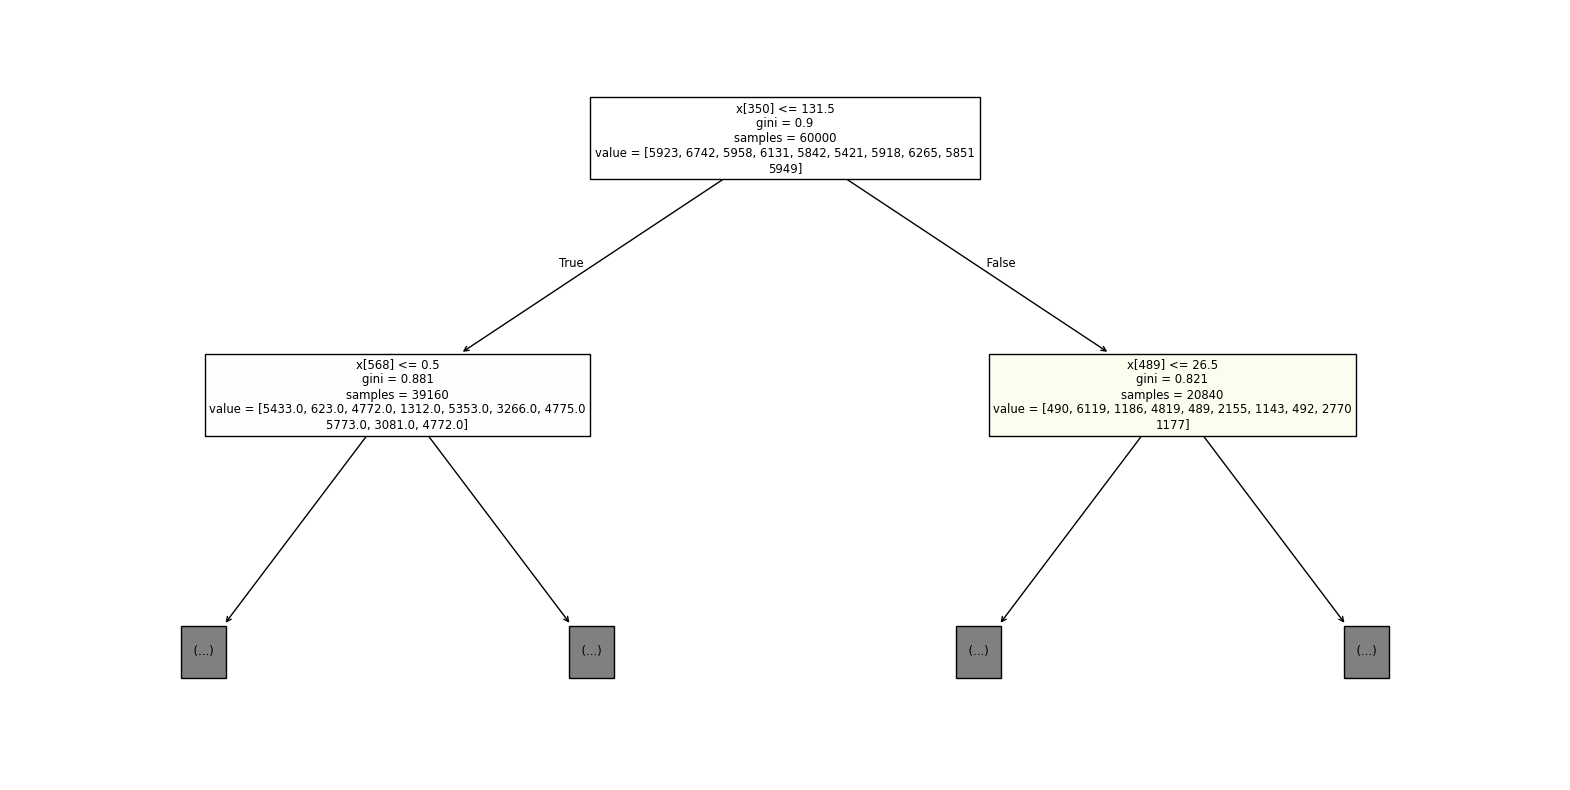

In [24]:

from sklearn import tree
plt.figure(figsize=(20,10))
tree.plot_tree(dt, max_depth=1, filled=True)
plt.show()


Laten we nu kijken of je betere resultaten kunt krijgen uit de features die je zelf eerder hebt bedacht.

In [25]:
# Features
def check_center(image):
    center_size = 8
    start = (image.shape[0] - center_size) // 2
    end = start + center_size
    center_square = image[start:end, start:end]
    score = center_square.mean() / 255.0
    return score

def vertical_symmetry(image):
    flipped = np.fliplr(image)
    diff = np.abs(image - flipped)
    score = 1 - (diff.mean() / 255.0)
    return score

def horizontal_symmetry(image):
    flipped = np.flipud(image)
    diff = np.abs(image - flipped)
    score = 1 - (diff.mean() / 255.0)
    return score

def top_bottom_balance(image):
    mid = image.shape[0] // 2
    top = image[:mid, :].mean()
    bottom = image[mid:, :].mean()
    return (top - bottom) / 255.0

def pixel_density(image):
    return image.mean() / 255.0

def left_right_balance(image):
    mid = image.shape[1] // 2
    left = image[:, :mid].mean()
    right = image[:, mid:].mean()
    return (left - right) / 255.0

def active_pixels(image):
    return np.sum(image > 50) / (28 * 28)

In [29]:

sort_method = {
    "center": check_center,
    "vertical_sim": vertical_symmetry,
    "horizontal_sim": horizontal_symmetry,
    "top-bottom-bal": top_bottom_balance,
    "left-right-bal": left_right_balance,
    "density": pixel_density,
    "active": active_pixels,
}

def make_image_feature_vector(image):
    features = []
    for method_name in sort_method:
        method = sort_method[method_name]
        features.append(method(image))
    return np.array(features)

def extract_features_batch(X_flat):
    imgs = X_flat.reshape(-1, 28, 28)
    feature_list = []

    for img in imgs:
        feats = make_image_feature_vector(img)   # Deze hebben jullie eerder gemaakt! Gebruik hier je oude extract_features functie
        feature_list.append(feats)

    return np.array(feature_list)       # shape: (n_samples, n_student_features)

#combineer de standaard features met jouw nieuwe features
# Dit is dus wat we hadden: (70000, 784)
# stel je hebt zelf 11 features aangemaakt
# Dan is dit wat het wordt: (70000, 784 + 11)


X_combined = np.hstack([train_images_flattend, extract_features_batch(train_images_flattend)])
print("Combined shape:", X_combined.shape)


Combined shape: (60000, 791)


- Heb je nu betere resultaten?

In [30]:
# make new desicion tree
dt = DecisionTreeClassifier(
    criterion='gini',
    max_depth=20,
    random_state=42
)

dt.fit(X_combined, train_labels)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

In [31]:
y_pred = dt.predict(np.hstack([test_images_flatted, extract_features_batch(test_images_flatted)]))


acc = accuracy_score(y_pred, test_labels)
print("Decision Tree Accuracy on MNIST:", acc)

print("\nClassification Report:")
print(classification_report(y_pred, test_labels))

Decision Tree Accuracy on MNIST: 0.8809

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.92      0.93      1000
           1       0.97      0.95      0.96      1156
           2       0.86      0.87      0.86      1016
           3       0.83      0.85      0.84       985
           4       0.89      0.87      0.88       997
           5       0.83      0.82      0.83       896
           6       0.88      0.90      0.89       944
           7       0.91      0.91      0.91      1025
           8       0.82      0.83      0.82       958
           9       0.87      0.86      0.86      1023

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



**Conclusie**

Er is een kleine daling in de voorspellende waarde 0.7% minder naukeurig.

En wat nou als je alleen je oude features gebruikt? 

In [32]:
# make new desicion tree
dt = DecisionTreeClassifier(
    criterion='gini',
    max_depth=20,
    random_state=42
)

dt.fit(extract_features_batch(train_images_flattend), train_labels)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

In [33]:
y_pred = dt.predict(extract_features_batch(test_images_flatted))


acc = accuracy_score(y_pred, test_labels)
print("Decision Tree Accuracy on MNIST:", acc)

print("\nClassification Report:")
print(classification_report(y_pred, test_labels))

Decision Tree Accuracy on MNIST: 0.51

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.75      0.75       971
           1       0.88      0.88      0.88      1137
           2       0.42      0.43      0.43      1012
           3       0.38      0.34      0.35      1127
           4       0.32      0.34      0.33       906
           5       0.33      0.32      0.33       902
           6       0.50      0.51      0.50       930
           7       0.60      0.65      0.63       953
           8       0.50      0.49      0.50       994
           9       0.36      0.34      0.35      1068

    accuracy                           0.51     10000
   macro avg       0.50      0.51      0.50     10000
weighted avg       0.51      0.51      0.51     10000



**Conclusie**

Met onze eigen features kan de decision tree een naukeurigheid bereieken van 51%
Opmerkelijk hierbij zijn de grote verschillen tussen getallen. zo hebben de 3 en 4 met 33% een bijzonder lage kans goed geraden te worden. de 1 heeft daarentegen een hoge kans goed geraden te worden met 88%.